# News_Category_Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_train=pd.read_csv('/content/train.csv')

df_test=pd.read_csv('/content/test.csv')

In [ ]:
df_train.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [ ]:
df_test.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [ ]:
df_train.tail()

,Class Index,Title,Description
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
119999,2,Nets get Carter from Raptors,INDIANAPOLIS -- All-Star Vince Carter was trad...


In [ ]:
df_test.tail()

,Class Index,Title,Description
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...
7599,3,EBay gets into rentals,EBay plans to buy the apartment and home renta...


In [ ]:
df_train.shape

(120000, 3)

In [ ]:
df_test.shape

(7600, 3)

In [ ]:
df_train.columns

Index(['Class Index', 'Title', 'Description'], dtype='object')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [ ]:
df_train.describe()

,Class Index
count,120000.000000
mean,2.500000
std,1.118039
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [ ]:
# missing values
df_train.isnull().sum()

,0
Class Index,0
Title,0
Description,0


In [ ]:
df_train.isnull().sum().sum()

np.int64(0)

In [ ]:
df_train.duplicated().sum()

np.int64(0)

In [ ]:
df_train['Class Index'].value_counts()

,count
Class Index,
3,30000
4,30000
2,30000
1,30000


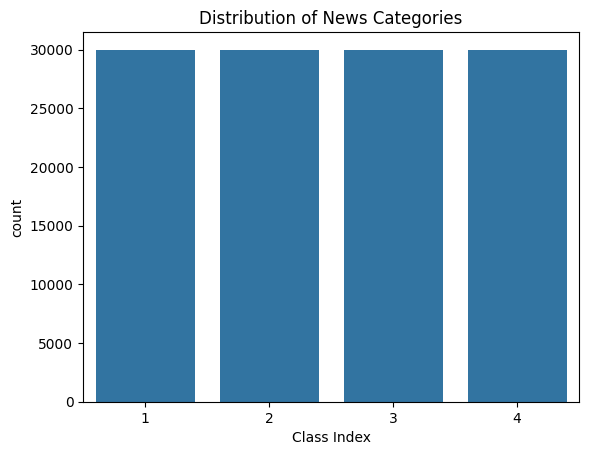

In [ ]:
sns.countplot(x="Class Index", data=df_train)
plt.title("Distribution of News Categories")
plt.show()

In [ ]:
# combining title and description
df_train["text"] = df_train["Title"] + " " + df_train["Description"]

df_test["text"] = df_test["Title"] + " " + df_test["Description"]

In [ ]:
# Lower casing
df_train["text"] = df_train["text"].str.lower()

df_test["text"] = df_test["text"].str.lower()

In [ ]:
# check for html
df_train["text"].str.contains(r"<.*?>", regex=True).sum()
df_test["text"].str.contains(r"<.*?>", regex=True).sum()

np.int64(0)

In [ ]:
# check for URLs
df_train["text"].str.contains(r"http\S+", regex=True).sum()
df_test["text"].str.contains(r"http\S+", regex=True).sum()

np.int64(99)

In [ ]:
# removing URLs
import re
df_train["text"]=df_train["text"].apply(lambda x: re.sub(r"http\S+", "", x))
df_test["text"]=df_test["text"].apply(lambda x: re.sub(r"http\S+", "", x))


In [ ]:
# Check for numbers
df_train["text"].str.contains(r"\d+", regex=True).sum()
df_test["text"].str.contains(r"\d+", regex=True).sum()

np.int64(4414)

In [ ]:
# Removing numbers
df_train["text"]=df_train["text"].apply(lambda x: re.sub(r"\d+", "", x))
df_test["text"]=df_test["text"].apply(lambda x: re.sub(r"\d+", "", x))

In [ ]:
# Removing Punctuations
df_train["text"]=df_train["text"].apply(lambda x: re.sub(r"[^\w\s]", "", x))
df_test["text"]=df_test["text"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [ ]:
print(type(df_train["text"].iloc[0]))
print(df_train["text"].loc[0])


<class 'str'>
wall st bears claw back into the black reuters reuters  shortsellers wall streets dwindlingband of ultracynics are seeing green again


In [ ]:
# Tokenization
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
df_train["text"]=df_train["text"].apply(word_tokenize)
df_test["text"]=df_test["text"].apply(word_tokenize)
print("tokenization done")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


tokenization done


In [ ]:
print(type(df_train["text"].iloc[0]))
print(df_train["text"].loc[0])

<class 'list'>
['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'of', 'ultracynics', 'are', 'seeing', 'green', 'again']


In [ ]:
# Removing Stop words
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=set(stopwords.words("english"))
df_train["text"]=df_train["text"].apply(lambda words: [word for word in words if word not in stop_words])
df_test["text"]=df_test["text"].apply(lambda words: [word for word in words if word not in stop_words])
print("stop words removed")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


stop words removed


In [ ]:
print(type(df_train["text"].iloc[0]))
print(df_train["text"].loc[0])

<class 'list'>
['wall', 'st', 'bears', 'claw', 'back', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'ultracynics', 'seeing', 'green']


In [ ]:
# Lemmatization
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer=WordNetLemmatizer()
df_train["text"]=df_train["text"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])
df_test["text"]=df_test["text"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])
print("lemmatization done")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


lemmatization done


In [ ]:
print(type(df_train["text"].iloc[0]))
print(df_train["text"].loc[0])

<class 'list'>
['wall', 'st', 'bear', 'claw', 'back', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'street', 'dwindlingband', 'ultracynics', 'seeing', 'green']


In [ ]:
# joining the words
df_train["text"]=df_train["text"].apply(lambda words: " ".join(words))
df_test["text"]=df_test["text"].apply(lambda words: " ".join(words))
print("joining done")

joining done


In [ ]:
print(type(df_train["text"].iloc[0]))
print(df_train["text"].loc[0])

<class 'str'>
wall st bear claw back black reuters reuters shortsellers wall street dwindlingband ultracynics seeing green


In [ ]:
# Tfidf Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer()
X_train=vectorizer.fit_transform(df_train["text"])
y_train=df_train["Class Index"]
X_test=vectorizer.transform(df_test["text"])
y_test=df_test["Class Index"]

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(120000, 83351)
(120000,)
(7600, 83351)
(7600,)


In [ ]:
# importing libraries
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
models={
    "MultinomialNB":MultinomialNB(),
    "LogisticRegression":LogisticRegression(),
    "LinearSVC":LinearSVC()
}
res={}
for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  res[name]=accuracy
  print(f"{name} accuracy: {accuracy}")
  print(classification_report(y_test,y_pred))
  print(confusion_matrix(y_test,y_pred))

MultinomialNB accuracy: 0.900921052631579
              precision    recall  f1-score   support

           1       0.91      0.89      0.90      1900
           2       0.95      0.98      0.96      1900
           3       0.86      0.86      0.86      1900
           4       0.88      0.87      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600

[[1694   63  102   41]
 [  21 1858   12    9]
 [  70   17 1638  175]
 [  72   19  152 1657]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression accuracy: 0.9164473684210527
              precision    recall  f1-score   support

           1       0.93      0.91      0.92      1900
           2       0.95      0.98      0.97      1900
           3       0.89      0.89      0.89      1900
           4       0.89      0.89      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

[[1724   55   72   49]
 [  18 1862   12    8]
 [  58   17 1682  143]
 [  55   16  132 1697]]
LinearSVC accuracy: 0.9173684210526316
              precision    recall  f1-score   support

           1       0.94      0.91      0.92      1900
           2       0.96      0.98      0.97      1900
           3       0.89      0.88      0.89      1900
           4       0.89      0.90      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weigh

In [ ]:
# Checking Accuracy
import pandas as pd

results_df = pd.DataFrame(
    res.items(),
    columns=["Model", "Accuracy"]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,LinearSVC,0.917368
1,LogisticRegression,0.916447
0,MultinomialNB,0.900921


In [ ]:
# Training bestmodel
best_model=LinearSVC()
best_model.fit(X_train,y_train)
y_pred=best_model.predict(X_test)

In [ ]:
# Accuracy and classification report
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.9173684210526316
              precision    recall  f1-score   support

           1       0.94      0.91      0.92      1900
           2       0.96      0.98      0.97      1900
           3       0.89      0.88      0.89      1900
           4       0.89      0.90      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

[[1720   54   73   53]
 [  16 1863   12    9]
 [  51   18 1679  152]
 [  50   13  127 1710]]


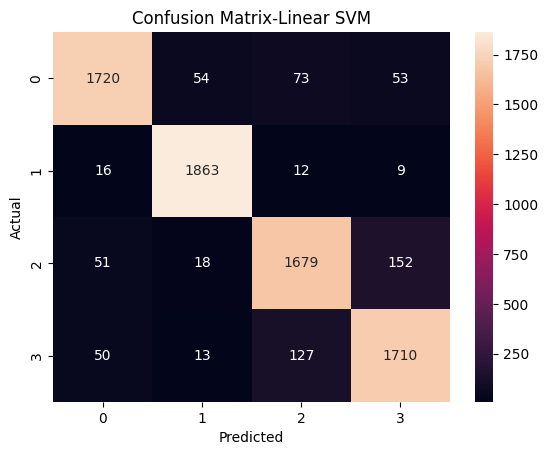

In [ ]:
# Plotting the data
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix-Linear SVM")
plt.show()

In [ ]:
# predection using test cases
def predict_news(news):

    news_tfidf = vectorizer.transform([news])

    prediction = best_model.predict(news_tfidf)[0]

    labels = {
        1: "World",
        2: "Sports",
        3: "Business",
        4: "Science/Technology"
    }

    return labels[prediction]

In [ ]:
print(predict_news("India defeated Australia by 6 wickets."))

Sports


In [ ]:
print(predict_news("Thailand government offered visa less vacation."))

World


In [ ]:
print(predict_news("The stock market reached an all-time high after strong earnings reports."))

Business


In [ ]:
# to save in pkl
import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']